# Referee Audit — Current State of the NSL-KDD IDS Project

**Role of this notebook:** middle negotiator / analyst / referee. It checks what currently runs, what the data says, what the results support, where the documentation has drifted, and what the next working-process improvements should be.

**Scope:** NSL-KDD only. The repo already downloaded UNSW-NB15 and CICIDS2017, but the standing convention is deliverable-first: finish NSL-KDD end-to-end before modelling the other datasets.

This audit was created after running:

```bash
.venv/bin/python src/preprocess.py
.venv/bin/python -m pytest -q
.venv/bin/python src/train_baselines.py
.venv/bin/python src/train_mlp.py
```

Set `RUN_EXPENSIVE_TRAINING = True` below if you want the notebook itself to rerun Phase 3/4 training. By default it verifies the runnable surface and analyzes the current saved results.


In [1]:
from __future__ import annotations

import os
import re
import sys
import subprocess
from pathlib import Path

CWD = Path.cwd().resolve()
if (CWD / "src").exists():
    REPO = CWD
elif (CWD.parent / "src").exists():
    REPO = CWD.parent
else:
    raise RuntimeError(f"Could not locate repo root from {CWD}")
SRC = REPO / "src"
sys.path.insert(0, str(SRC))

# Headless-safe plotting for notebook/script execution.
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".matplotlib-cache"))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import data as D
import preprocess as P

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

RUN_EXPENSIVE_TRAINING = False
print(f"repo: {REPO}")
print(f"python: {sys.executable}")


repo: /Users/guneyaliunal/Desktop/don't delete/dazed&confused/nsl-kdd-ids
python: /Users/guneyaliunal/Desktop/don't delete/dazed&confused/nsl-kdd-ids/.venv/bin/python


## 1. What I am checking and why

The project is trying to prove a specific claim: **a security-aware ML workflow can detect broad attack behavior, but honest evaluation exposes failure on rare and novel attacks.**

This notebook checks:

1. **Runnability:** do preprocessing and tests pass right now?
2. **Data reality:** what class imbalance and train/test shift are we dealing with?
3. **Model evidence:** do current metrics support the written conclusions?
4. **Process quality:** what would make the project more reproducible, reviewer-friendly, and interview-defensible?


In [2]:
def run_cmd(cmd: list[str], timeout: int = 120) -> subprocess.CompletedProcess:
    # Compact command runner used for audit traceability.
    print("$", " ".join(cmd))
    out = subprocess.run(
        cmd,
        cwd=REPO,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    print(out.stdout[-4000:])
    print("exit:", out.returncode)
    return out

preprocess_check = run_cmd([str(REPO / ".venv" / "bin" / "python"), "src/preprocess.py"], timeout=60)
test_check = run_cmd([str(REPO / ".venv" / "bin" / "python"), "-m", "pytest", "-q"], timeout=120)
assert preprocess_check.returncode == 0
assert test_check.returncode == 0


$ /Users/guneyaliunal/Desktop/don't delete/dazed&confused/nsl-kdd-ids/.venv/bin/python src/preprocess.py



[binary]  X_train (125973, 122)  X_test (22544, 122)
  features after one-hot: 122 (from 41 raw)
  classes (int order): [(0, 'normal'), (1, 'attack')]
  train counts: normal=67,343, attack=58,630
  test counts: normal=9,711, attack=12,833

[multiclass]  X_train (125973, 122)  X_test (22544, 122)
  features after one-hot: 122 (from 41 raw)
  classes (int order): [(0, 'normal'), (1, 'DoS'), (2, 'Probe'), (3, 'R2L'), (4, 'U2R')]
  train counts: normal=67,343, DoS=45,927, Probe=11,656, R2L=995, U2R=52
  test counts: normal=9,711, DoS=7,460, Probe=2,421, R2L=2,885, U2R=67

All checks passed.

exit: 0
$ /Users/guneyaliunal/Desktop/don't delete/dazed&confused/nsl-kdd-ids/.venv/bin/python -m pytest -q


...................................                                      [100%]

exit: 0


### Optional: full retraining commands

These commands rewrite `results/metrics.md` and several figures. They are off by default because this audit should be runnable quickly, but the project should still support them.


In [3]:
if RUN_EXPENSIVE_TRAINING:
    run_cmd([str(REPO / ".venv" / "bin" / "python"), "src/train_baselines.py"], timeout=600)
    run_cmd([str(REPO / ".venv" / "bin" / "python"), "src/train_mlp.py"], timeout=600)
else:
    print("Skipping expensive training inside notebook. Using current results/metrics.md and figures.")


Skipping expensive training inside notebook. Using current results/metrics.md and figures.


## 2. Current project inventory

This is a quick structural check: what files exist, and what phase artifacts are present?


In [4]:
interesting = [
    "src/data.py", "src/preprocess.py", "src/evaluate.py", "src/train_baselines.py", "src/train_mlp.py",
    "results/metrics.md", "docs/PROGRESS.md", "docs/learning/02_baselines.md", "docs/learning/03_mlp.md",
]
for rel in interesting:
    p = REPO / rel
    print(f"{rel:38s} {'OK' if p.exists() else 'MISSING'}")

figs = sorted((REPO / "results" / "figures").glob("*.png"))
print(f"\nfigure count: {len(figs)}")
for p in figs:
    print("-", p.name)


src/data.py                            OK
src/preprocess.py                      OK
src/evaluate.py                        OK
src/train_baselines.py                 OK
src/train_mlp.py                       OK
results/metrics.md                     OK
docs/PROGRESS.md                       OK
docs/learning/02_baselines.md          OK
docs/learning/03_mlp.md                OK

figure count: 23
- p1_categorical_by_class.png
- p1_class_distribution.png
- p1_correlation_heatmap.png
- p1_feature_distributions.png
- p1_top_attack_types.png
- p3_nslkdd_lightgbm_binary_importance.png
- p3_nslkdd_lightgbm_binary_test21_confusion.png
- p3_nslkdd_lightgbm_binary_test21_roc_pr.png
- p3_nslkdd_lightgbm_binary_test_confusion.png
- p3_nslkdd_lightgbm_binary_test_roc_pr.png
- p3_nslkdd_lightgbm_multiclass_importance.png
- p3_nslkdd_lightgbm_multiclass_test_confusion.png
- p3_nslkdd_randomforest_binary_importance.png
- p3_nslkdd_randomforest_binary_test21_confusion.png
- p3_nslkdd_randomforest_binary_t

## 2a. Code-path audit: what the project actually does now

This section reads the source files as evidence. The point is to separate the implemented pipeline from the project narrative: what modules exist, what functions/classes they expose, and which guardrails are present in code.


In [5]:
import ast

module_files = [
    REPO / "src/data.py",
    REPO / "src/preprocess.py",
    REPO / "src/evaluate.py",
    REPO / "src/train_baselines.py",
    REPO / "src/train_mlp.py",
]

code_rows = []
for path in module_files:
    text = path.read_text(encoding="utf-8")
    tree = ast.parse(text)
    funcs = [node.name for node in tree.body if isinstance(node, ast.FunctionDef)]
    classes = [node.name for node in tree.body if isinstance(node, ast.ClassDef)]
    guardrails = []
    if "fit_transform(train" in text or "pre.fit_transform(train" in text:
        guardrails.append("fit preprocessor on train")
    if "pre.transform(test" in text:
        guardrails.append("transform test only")
    if 'handle_unknown="ignore"' in text:
        guardrails.append("ignore unseen categories")
    if "StratifiedKFold" in text and "GridSearchCV" in text:
        guardrails.append("CV on train")
    if "num_threads=1" in text or "OMP_NUM_THREADS" in text:
        guardrails.append("OpenMP-safe threading")
    if 'matplotlib.use("Agg")' in text:
        guardrails.append("headless plotting")
    if "CrossEntropyLoss(weight=" in text:
        guardrails.append("optional class-weighted loss")
    code_rows.append({
        "module": path.name,
        "lines": len(text.splitlines()),
        "public classes": ", ".join(classes) or "-",
        "public functions": ", ".join(funcs[:8]) + (" ..." if len(funcs) > 8 else ""),
        "guardrails seen": "; ".join(guardrails) or "-",
    })

code_inventory = pd.DataFrame(code_rows)
display(code_inventory)


,module,lines,public classes,public functions,guardrails seen
0,data.py,139,-,"load_nsl_kdd, add_label_columns",-
1,preprocess.py,210,PreparedData,"build_preprocessor, _feature_names, prepare, p...",fit preprocessor on train; transform test only...
2,evaluate.py,168,-,"compute_metrics, plot_confusion_matrices, plot...",headless plotting
3,train_baselines.py,167,-,"tune_and_fit, evaluate_on, render_metrics_md, ...",CV on train; OpenMP-safe threading
4,train_mlp.py,208,MLP,"get_device, set_seed, compute_class_weights, _...",optional class-weighted loss


**Referee read:** the project is not just a notebook experiment anymore. The code has distinct responsibilities: `data.py` loads/labels, `preprocess.py` creates leakage-safe matrices, `evaluate.py` scores/plots, `train_baselines.py` runs classical tree baselines, and `train_mlp.py` runs the neural ablation. The main implementation risk is no longer missing plumbing; it is whether the model set is broad enough to justify the story.


## 3. Data audit: class balance and train/test shift

This is the first major analytical point. If the data is heavily imbalanced or the test set has a different attack mix, then accuracy becomes a weak headline metric. Macro-F1 and per-class recall become the honest metrics.


In [6]:
train = D.load_nsl_kdd("train")
test = D.load_nsl_kdd("test")
test21 = D.load_nsl_kdd("test-21")

family_counts = pd.DataFrame({
    "train": train["attack_family"].value_counts().reindex(D.FAMILY_ORDER),
    "test": test["attack_family"].value_counts().reindex(D.FAMILY_ORDER),
    "test-21": test21["attack_family"].value_counts().reindex(D.FAMILY_ORDER),
}).fillna(0).astype(int)

family_pct = family_counts.div(family_counts.sum(axis=0), axis=1) * 100
shift = pd.DataFrame({
    "train_%": family_pct["train"],
    "test_%": family_pct["test"],
    "test_minus_train_pp": family_pct["test"] - family_pct["train"],
})

display(family_counts)
display(shift.round(2))


,train,test,test-21
attack_family,,,
normal,67343,9711,2152
DoS,45927,7460,4344
Probe,11656,2421,2402
R2L,995,2885,2885
U2R,52,67,67


,train_%,test_%,test_minus_train_pp
attack_family,,,
normal,53.46,43.08,-10.38
DoS,36.46,33.09,-3.37
Probe,9.25,10.74,1.49
R2L,0.79,12.80,12.01
U2R,0.04,0.30,0.26


In [7]:
train_labels = set(train["label"].unique())
test_labels = set(test["label"].unique())
unseen_in_test = sorted(test_labels - train_labels)
train_only = sorted(train_labels - test_labels)

print(f"raw attack labels in train: {len(train_labels)}")
print(f"raw attack labels in test:  {len(test_labels)}")
print(f"test labels unseen during training: {len(unseen_in_test)}")
print(unseen_in_test)
print(f"\ntrain-only labels: {len(train_only)}")
print(train_only)


raw attack labels in train: 23
raw attack labels in test:  38
test labels unseen during training: 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']

train-only labels: 2
['spy', 'warezclient']


**Referee read:** the test set is not just a smaller copy of the train set. R2L jumps from under 1% of train to roughly 13% of test, and the raw test labels include attack names that are not present during training. That is exactly why train/CV performance can look excellent while official-test performance drops.


## 3a. Quantified shift audit: what changes between train and test

The official NSL-KDD split is intentionally harsh. Here I quantify three kinds of shift: class mix shift, numeric feature drift, and categorical distribution drift. This matters because a model can be excellent on train-like folds and still fail when the test set has different attack families and traffic patterns.


In [8]:
# Label-family distribution shift.
family_shift = pd.concat([
    train["attack_family"].value_counts(normalize=True).rename("train_share"),
    test["attack_family"].value_counts(normalize=True).rename("test_share"),
], axis=1).fillna(0)
family_shift["test_minus_train_pp"] = 100 * (family_shift["test_share"] - family_shift["train_share"])
family_shift = family_shift.loc[D.FAMILY_ORDER]
display(family_shift.style.format({"train_share": "{:.3%}", "test_share": "{:.3%}", "test_minus_train_pp": "{:+.2f}"}))

# Numeric drift: standardized mean difference using train standard deviation.
num_rows = []
for col in D.NUMERIC_COLS:
    tr = train[col].astype(float)
    te = test[col].astype(float)
    tr_std = tr.std(ddof=0)
    smd = abs(te.mean() - tr.mean()) / (tr_std if tr_std > 0 else np.nan)
    num_rows.append({
        "feature": col,
        "train_mean": tr.mean(),
        "test_mean": te.mean(),
        "train_std": tr_std,
        "abs_standardized_mean_shift": smd,
    })
numeric_shift = pd.DataFrame(num_rows).sort_values("abs_standardized_mean_shift", ascending=False)
display(numeric_shift.head(12).style.format({
    "train_mean": "{:.3f}", "test_mean": "{:.3f}", "train_std": "{:.3f}", "abs_standardized_mean_shift": "{:.2f}"
}))

# Categorical drift: total variation distance between train/test distributions.
cat_rows = []
for col in D.CATEGORICAL_COLS:
    tr = train[col].value_counts(normalize=True)
    te = test[col].value_counts(normalize=True)
    cats = sorted(set(tr.index) | set(te.index))
    trv = tr.reindex(cats, fill_value=0)
    tev = te.reindex(cats, fill_value=0)
    tvd = 0.5 * np.abs(trv - tev).sum()
    biggest = (tev - trv).abs().sort_values(ascending=False).head(3)
    cat_rows.append({
        "feature": col,
        "train_unique": train[col].nunique(),
        "test_unique": test[col].nunique(),
        "test_only_values": len(set(test[col]) - set(train[col])),
        "total_variation_distance": tvd,
        "largest_category_shifts": ", ".join(f"{k}: {100*(tev[k]-trv[k]):+.1f}pp" for k in biggest.index),
    })
cat_shift = pd.DataFrame(cat_rows).sort_values("total_variation_distance", ascending=False)
display(cat_shift.style.format({"total_variation_distance": "{:.3f}"}))


,train_share,test_share,test_minus_train_pp
attack_family,,,
normal,53.458%,43.076%,-10.38
DoS,36.458%,33.091%,-3.37
Probe,9.253%,10.739%,+1.49
R2L,0.790%,12.797%,+12.01
U2R,0.041%,0.297%,+0.26


,feature,train_mean,test_mean,train_std,abs_standardized_mean_shift
7,num_failed_logins,0.001,0.022,0.045,0.45
34,dst_host_serror_rate,0.284,0.098,0.445,0.42
21,serror_rate,0.284,0.103,0.446,0.41
35,dst_host_srv_serror_rate,0.278,0.099,0.446,0.40
22,srv_serror_rate,0.282,0.104,0.447,0.40
36,dst_host_rerror_rate,0.119,0.233,0.307,0.37
23,rerror_rate,0.120,0.238,0.320,0.37
24,srv_rerror_rate,0.121,0.235,0.324,0.35
37,dst_host_srv_rerror_rate,0.120,0.227,0.319,0.33
29,dst_host_srv_count,115.653,140.751,110.702,0.23


,feature,train_unique,test_unique,test_only_values,total_variation_distance,largest_category_shifts
1,service,70,64,0,0.205,"telnet: +5.3pp, pop_3: +4.3pp, private: +3.8pp"
2,flag,11,11,0,0.191,"S0: -18.7pp, REJ: +8.2pp, SF: +6.5pp"
0,protocol_type,3,3,0,0.022,"tcp: +2.2pp, icmp: -2.0pp, udp: -0.3pp"


**Referee read:** the split shift is measurable, not hand-wavy. R2L is much more common in test than train, several numeric traffic-rate features move substantially, and categorical service/flag distributions are not identical. This is why train-fold cross-validation alone is not enough evidence for a deployed intrusion detector.


## 4. Preprocessing audit: leakage guard and dimensionality

The preprocessing file is the heart of Phase 2. The key rule is still: **fit on train, transform test.** The audit below checks shape, NaNs, class order, and where the 122 columns come from.


In [9]:
prep_bin = P.prepare_nsl_kdd("binary")
prep_multi = P.prepare_nsl_kdd("multiclass")

prep_summary = pd.DataFrame([
    {"scheme": "binary", "X_train": prep_bin.X_train.shape, "X_test": prep_bin.X_test.shape, "classes": prep_bin.classes},
    {"scheme": "multiclass", "X_train": prep_multi.X_train.shape, "X_test": prep_multi.X_test.shape, "classes": prep_multi.classes},
])
display(prep_summary)

assert not np.isnan(prep_bin.X_train).any()
assert not np.isnan(prep_bin.X_test).any()
assert not np.isnan(prep_multi.X_train).any()
assert not np.isnan(prep_multi.X_test).any()

feature_names = prep_multi.feature_names
cat_feature_names = [f for f in feature_names if f not in D.NUMERIC_COLS]
print(f"raw features: {len(D.FEATURE_NAMES)}")
print(f"numeric columns kept/scaled: {len(D.NUMERIC_COLS)}")
print(f"one-hot categorical output columns: {len(cat_feature_names)}")
print(f"final model columns: {len(feature_names)}")
print(f"extra columns vs raw: {len(feature_names) - len(D.FEATURE_NAMES)}")


,scheme,X_train,X_test,classes
0,binary,"(125973, 122)","(22544, 122)","[normal, attack]"
1,multiclass,"(125973, 122)","(22544, 122)","[normal, DoS, Probe, R2L, U2R]"


raw features: 41
numeric columns kept/scaled: 38
one-hot categorical output columns: 84
final model columns: 122
extra columns vs raw: 81


In [10]:
unseen_by_cat = []
for col in D.CATEGORICAL_COLS:
    tr = set(train[col].unique())
    te = set(test[col].unique())
    unseen_by_cat.append({
        "column": col,
        "train_categories": len(tr),
        "test_categories": len(te),
        "unseen_in_test": len(te - tr),
        "unseen_values": sorted(te - tr),
    })
display(pd.DataFrame(unseen_by_cat))


,column,train_categories,test_categories,unseen_in_test,unseen_values
0,protocol_type,3,3,0,[]
1,service,70,64,0,[]
2,flag,11,11,0,[]


**Referee read:** the preprocessing design is sound. One-hot expansion explains the jump from 41 raw features to 122 model columns. `handle_unknown='ignore'` is still right even when this specific NSL-KDD split has no unseen categorical values, because the pipeline is meant to survive future splits/datasets/deployment traffic.


## 5. Metrics parser: current saved evidence

Now we read `results/metrics.md`, not the chat log. This matters because a project write-up must match the files currently in the repo.


In [11]:
metrics_text = (REPO / "results" / "metrics.md").read_text(encoding="utf-8")
print(metrics_text[:1600])


# NSL-KDD — Phase 3 baseline results (RF vs LightGBM)

Official split; metrics on the held-out test set. Leading with **macro-F1** and per-class recall (accuracy is inflated by the easy majority classes).

| Model | Task | Test set | Accuracy | Macro-F1 | Weighted-F1 | ROC-AUC | PR-AUC | Best params |
| --- | --- | --- | ---: | ---: | ---: | ---: | ---: | --- |
| RandomForest | binary | KDDTest+ | 0.7772 | 0.7763 | 0.7744 | 0.9620 | 0.9651 | `{'max_depth': None, 'n_estimators': 300}` |
| RandomForest | binary | KDDTest-21 | 0.5761 | 0.5462 | 0.6204 | 0.8177 | 0.9447 | `{'max_depth': None, 'n_estimators': 300}` |
| LightGBM | binary | KDDTest+ | 0.7850 | 0.7845 | 0.7829 | 0.9608 | 0.9628 | `{'n_estimators': 400, 'num_leaves': 31}` |
| LightGBM | binary | KDDTest-21 | 0.5911 | 0.5579 | 0.6351 | 0.7889 | 0.9321 | `{'n_estimators': 400, 'num_leaves': 31}` |
| RandomForest | multiclass | KDDTest+ | 0.7430 | 0.5038 | 0.7019 | — | — | `{'max_depth': 25, 'n_estimators': 300}` |
| LightGBM | mu

In [12]:
def parse_markdown_table_after(text: str, heading: str) -> pd.DataFrame:
    start = text.index(heading)
    lines = text[start:].splitlines()
    table_lines = []
    in_table = False
    for line in lines:
        if line.startswith("| "):
            table_lines.append(line)
            in_table = True
        elif in_table:
            break
    rows = []
    headers = [h.strip() for h in table_lines[0].strip("|").split("|")]
    for line in table_lines[2:]:
        vals = [v.strip().strip("`") for v in line.strip("|").split("|")]
        rows.append(dict(zip(headers, vals)))
    return pd.DataFrame(rows)

baseline_df = parse_markdown_table_after(metrics_text, "| Model | Task | Test set |")
mlp_df = parse_markdown_table_after(metrics_text, "| Variant | Task | Accuracy |")

for df in (baseline_df, mlp_df):
    for col in ["Accuracy", "Macro-F1", "Weighted-F1", "ROC-AUC", "PR-AUC"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace("—", np.nan), errors="coerce")

display(baseline_df)
display(mlp_df)


,Model,Task,Test set,Accuracy,Macro-F1,Weighted-F1,ROC-AUC,PR-AUC,Best params
0,RandomForest,binary,KDDTest+,0.7772,0.7763,0.7744,0.9620,0.9651,"{'max_depth': None, 'n_estimators': 300}"
1,RandomForest,binary,KDDTest-21,0.5761,0.5462,0.6204,0.8177,0.9447,"{'max_depth': None, 'n_estimators': 300}"
2,LightGBM,binary,KDDTest+,0.7850,0.7845,0.7829,0.9608,0.9628,"{'n_estimators': 400, 'num_leaves': 31}"
3,LightGBM,binary,KDDTest-21,0.5911,0.5579,0.6351,0.7889,0.9321,"{'n_estimators': 400, 'num_leaves': 31}"
4,RandomForest,multiclass,KDDTest+,0.7430,0.5038,0.7019,NaN,NaN,"{'max_depth': 25, 'n_estimators': 300}"
5,LightGBM,multiclass,KDDTest+,0.5614,0.2806,0.4932,NaN,NaN,"{'n_estimators': 400, 'num_leaves': 31}"


,Variant,Task,Accuracy,Macro-F1,Rare-class recall
0,MLP (unweighted),binary,0.8105,0.8104,attack 0.688
1,MLP (weighted),binary,0.7975,0.7975,attack 0.700
2,MLP (unweighted),multiclass,0.7484,0.5634,R2L 0.013 / U2R 0.269
3,MLP (weighted),multiclass,0.7764,0.5605,R2L 0.122 / U2R 0.537


## 6. Model comparison: what the current numbers say

This comparison is intentionally metric-first. Accuracy is included, but the judgment comes from macro-F1 and rare-class recall.


In [13]:
base_comp = baseline_df[baseline_df["Test set"] == "KDDTest+"].copy()
base_comp = base_comp.rename(columns={"Model": "Variant"})[["Variant", "Task", "Accuracy", "Macro-F1"]]
mlp_comp = mlp_df[["Variant", "Task", "Accuracy", "Macro-F1"]].copy()
comparison = pd.concat([base_comp, mlp_comp], ignore_index=True)
comparison = comparison.sort_values(["Task", "Macro-F1"], ascending=[True, False])
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = comparison.copy()
plot_df["label"] = plot_df["Variant"] + " / " + plot_df["Task"]
ax.barh(plot_df["label"], plot_df["Macro-F1"], color="#4C72B0")
ax.set_xlabel("Macro-F1")
ax.set_title("Current NSL-KDD model comparison by macro-F1")
ax.invert_yaxis()
for i, v in enumerate(plot_df["Macro-F1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


,Variant,Task,Accuracy,Macro-F1
4,MLP (unweighted),binary,0.8105,0.8104
5,MLP (weighted),binary,0.7975,0.7975
1,LightGBM,binary,0.7850,0.7845
0,RandomForest,binary,0.7772,0.7763
6,MLP (unweighted),multiclass,0.7484,0.5634
7,MLP (weighted),multiclass,0.7764,0.5605
2,RandomForest,multiclass,0.7430,0.5038
3,LightGBM,multiclass,0.5614,0.2806


/var/folders/3p/tfl6pl854pz2syby9jh11zdr0000gn/T/ipykernel_32226/2496006855.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Interpretation from the current run

- **Binary task:** the MLP variants currently beat RF/LightGBM on macro-F1. LightGBM is the best tree baseline, but the MLP is ahead on the saved current run.
- **Multiclass task:** both tree baselines struggle badly on R2L/U2R. The current MLP run is better than trees on macro-F1, but **not as strong as the older learning note claims**.
- **Hard subset:** binary performance drops heavily on KDDTest-21. That supports the generalization/staleness story.


## 7. Rare-class analysis: the SOC-critical part

For intrusion detection, the scariest errors are false negatives on attacks. In multiclass mode, R2L and U2R are the important stress test: they are rare, stealthier, and operationally dangerous.


In [14]:
blocks = re.split(r"\n\*\*", metrics_text)
per_class_rows = []
for block in blocks:
    if " — " not in block or "| class | precision" not in block:
        continue
    title = block.split("**", 1)[0].strip()
    model, task = [x.strip() for x in title.split("—")]
    table_part = "| class | precision" + block.split("| class | precision", 1)[1]
    for line in table_part.splitlines()[2:]:
        if not line.startswith("|"):
            break
        vals = [v.strip().replace(",", "") for v in line.strip("|").split("|")]
        if len(vals) == 5:
            per_class_rows.append({
                "Model": model,
                "Task": task,
                "class": vals[0],
                "precision": float(vals[1]),
                "recall": float(vals[2]),
                "f1": float(vals[3]),
                "support": int(vals[4]),
            })
per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)

rare_tree = per_class_df[(per_class_df["Task"] == "multiclass") & (per_class_df["class"].isin(["R2L", "U2R"]))]
display(rare_tree[["Model", "class", "precision", "recall", "f1", "support"]])


,Model,Task,class,precision,recall,f1,support
0,RandomForest,binary,normal,0.6649,0.9733,0.7901,9711
1,RandomForest,binary,attack,0.9689,0.6288,0.7626,12833
2,LightGBM,binary,normal,0.6737,0.9717,0.7957,9711
3,LightGBM,binary,attack,0.9678,0.6438,0.7732,12833
4,RandomForest,multiclass,normal,0.6431,0.9737,0.7746,9711
5,RandomForest,multiclass,DoS,0.9611,0.7651,0.8520,7460
6,RandomForest,multiclass,Probe,0.8223,0.5964,0.6914,2421
7,RandomForest,multiclass,R2L,0.9857,0.0478,0.0912,2885
8,RandomForest,multiclass,U2R,0.6667,0.0597,0.1096,67
9,LightGBM,multiclass,normal,0.5036,0.9358,0.6548,9711


,Model,class,precision,recall,f1,support
7,RandomForest,R2L,0.9857,0.0478,0.0912,2885
8,RandomForest,U2R,0.6667,0.0597,0.1096,67
12,LightGBM,R2L,0.0112,0.0007,0.0013,2885
13,LightGBM,U2R,0.0000,0.0000,0.0000,67


In [15]:
rare_mlp = mlp_df[mlp_df["Task"] == "multiclass"][["Variant", "Macro-F1", "Rare-class recall"]]
display(rare_mlp)


,Variant,Macro-F1,Rare-class recall
2,MLP (unweighted),0.5634,R2L 0.013 / U2R 0.269
3,MLP (weighted),0.5605,R2L 0.122 / U2R 0.537


**Referee read:** the current run still supports the core thesis: rare classes are the weak point, and imbalance-aware learning changes the rare-class behavior. But the exact MLP conclusion is now weaker and less stable than the old note: the current weighted MLP improves R2L/U2R recall but does not improve macro-F1 over the current unweighted MLP.


## 7a. Referee-only alternative models and training methods

These are **diagnostic audit runs**, not replacements for `results/metrics.md`. I train simple additional models on the same leakage-safe matrices and official test split to answer: are the current conclusions specific to RF/LightGBM/MLP, or do simpler training choices change the story?

Models/training methods covered:

- Dummy majority classifier: sanity floor.
- Logistic regression: simple linear baseline on the one-hot + scaled matrix.
- Balanced logistic regression: same model, inverse-frequency class weighting.
- ExtraTrees: a fast tree ensemble, with and without class weighting, trained on a stratified 30k-row audit subset to keep the notebook light.
- HistGradientBoosting with sample weights: a sklearn boosting check, also on the audit subset.
- Binary threshold tuning: choose a threshold on a validation split for attack-focused F2, then evaluate on test.


In [16]:
import time
import warnings
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
AUDIT_TREE_TRAIN_LIMIT = 30_000
RNG = D.RANDOM_STATE

def stratified_subset(X, y, limit=AUDIT_TREE_TRAIN_LIMIT):
    if len(y) <= limit:
        return X, y, len(y), "full train"
    idx, _ = train_test_split(
        np.arange(len(y)), train_size=limit, stratify=y, random_state=RNG
    )
    return X[idx], y[idx], len(idx), f"stratified {limit:,} rows"

def summarize_predictions(prep, y_pred, model_name, training_method, train_rows, seconds):
    labels = list(range(len(prep.classes)))
    p, r, f1, support = precision_recall_fscore_support(
        prep.y_test, y_pred, labels=labels, zero_division=0
    )
    row = {
        "Task": prep.scheme,
        "Model": model_name,
        "Training method": training_method,
        "Train rows used": train_rows,
        "Accuracy": accuracy_score(prep.y_test, y_pred),
        "Macro-F1": f1_score(prep.y_test, y_pred, average="macro", zero_division=0),
        "Weighted-F1": f1_score(prep.y_test, y_pred, average="weighted", zero_division=0),
        "seconds": seconds,
    }
    for i, name in enumerate(prep.classes):
        row[f"recall:{name}"] = r[i]
        row[f"f1:{name}"] = f1[i]
    return row

audit_rows = []
for scheme in ("binary", "multiclass"):
    prep = P.prepare_nsl_kdd(scheme)
    X_sub, y_sub, n_sub, subset_note = stratified_subset(prep.X_train, prep.y_train)

    specs = [
        ("Dummy", "most frequent class", DummyClassifier(strategy="most_frequent"), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("LogisticRegression", "unweighted full train", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("LogisticRegression", "class_weight='balanced' full train", LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("ExtraTrees", f"unweighted {subset_note}", ExtraTreesClassifier(n_estimators=120, max_depth=25, random_state=RNG, n_jobs=1), X_sub, y_sub, n_sub, None),
        ("ExtraTrees", f"class_weight='balanced' {subset_note}", ExtraTreesClassifier(n_estimators=120, max_depth=25, class_weight="balanced", random_state=RNG, n_jobs=1), X_sub, y_sub, n_sub, None),
        ("HistGradientBoosting", f"sample_weight='balanced' {subset_note}", HistGradientBoostingClassifier(max_iter=120, learning_rate=0.08, max_leaf_nodes=31, random_state=RNG), X_sub, y_sub, n_sub, "sample_weight"),
    ]

    for model_name, method, model, X_fit, y_fit, rows_used, fit_mode in specs:
        start = time.time()
        if fit_mode == "sample_weight":
            model.fit(X_fit, y_fit, sample_weight=compute_sample_weight("balanced", y_fit))
        else:
            model.fit(X_fit, y_fit)
        pred = model.predict(prep.X_test)
        audit_rows.append(summarize_predictions(prep, pred, model_name, method, rows_used, time.time() - start))

# Binary threshold tuning: fit on train split, tune threshold on validation only, then apply to official test.
prep = P.prepare_nsl_kdd("binary")
X_fit, X_val, y_fit, y_val = train_test_split(
    prep.X_train, prep.y_train, test_size=0.20, stratify=prep.y_train, random_state=RNG
)
start = time.time()
thr_model = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG)
thr_model.fit(X_fit, y_fit)
val_score = thr_model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
val_f2 = [fbeta_score(y_val, val_score >= t, beta=2, pos_label=1, zero_division=0) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(val_f2))])
test_score = thr_model.predict_proba(prep.X_test)[:, 1]
tuned_pred = (test_score >= best_threshold).astype(int)
audit_rows.append(summarize_predictions(
    prep, tuned_pred, "LogisticRegression", f"balanced + validation-tuned F2 threshold={best_threshold:.2f}", len(y_fit), time.time() - start
))

audit_df = pd.DataFrame(audit_rows)
num_cols = [c for c in audit_df.columns if c.startswith("recall:") or c.startswith("f1:") or c in ["Accuracy", "Macro-F1", "Weighted-F1", "seconds"]]
for c in num_cols:
    audit_df[c] = pd.to_numeric(audit_df[c], errors="coerce")

display(audit_df.sort_values(["Task", "Macro-F1"], ascending=[True, False]).style.format({
    "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}", "seconds": "{:.1f}",
    **{c: "{:.3f}" for c in audit_df.columns if c.startswith("recall:") or c.startswith("f1:")}
}))


,Task,Model,Training method,Train rows used,Accuracy,Macro-F1,Weighted-F1,seconds,recall:normal,f1:normal,recall:attack,f1:attack,recall:DoS,f1:DoS,recall:Probe,f1:Probe,recall:R2L,f1:R2L,recall:U2R,f1:U2R
3,binary,ExtraTrees,"unweighted stratified 30,000 rows",30000,0.7859,0.7854,0.7840,1.0,0.969,0.796,0.647,0.775,nan,nan,nan,nan,nan,nan,nan,nan
12,binary,LogisticRegression,balanced + validation-tuned F2 threshold=0.17,100778,0.7795,0.7795,0.7794,0.6,0.908,0.780,0.682,0.779,nan,nan,nan,nan,nan,nan,nan,nan
5,binary,HistGradientBoosting,"sample_weight='balanced' stratified 30,000 rows",30000,0.7744,0.7734,0.7714,1.6,0.973,0.788,0.624,0.759,nan,nan,nan,nan,nan,nan,nan,nan
4,binary,ExtraTrees,"class_weight='balanced' stratified 30,000 rows",30000,0.7737,0.7733,0.7720,1.0,0.948,0.783,0.642,0.764,nan,nan,nan,nan,nan,nan,nan,nan
2,binary,LogisticRegression,class_weight='balanced' full train,125973,0.7543,0.7539,0.7524,0.5,0.925,0.764,0.625,0.743,nan,nan,nan,nan,nan,nan,nan,nan
1,binary,LogisticRegression,unweighted full train,125973,0.7540,0.7535,0.7520,0.5,0.926,0.764,0.624,0.743,nan,nan,nan,nan,nan,nan,nan,nan
0,binary,Dummy,most frequent class,125973,0.4308,0.3011,0.2594,0.0,1.000,0.602,0.000,0.000,nan,nan,nan,nan,nan,nan,nan,nan
8,multiclass,LogisticRegression,class_weight='balanced' full train,125973,0.7913,0.6069,0.7775,7.2,0.914,0.815,nan,nan,0.830,0.872,0.847,0.835,0.236,0.374,0.552,0.139
7,multiclass,LogisticRegression,unweighted full train,125973,0.7602,0.5679,0.7150,2.1,0.930,0.775,nan,nan,0.829,0.872,0.769,0.820,0.014,0.028,0.224,0.345
11,multiclass,HistGradientBoosting,"sample_weight='balanced' stratified 30,000 rows",30000,0.7709,0.5546,0.7302,2.5,0.972,0.796,nan,nan,0.782,0.864,0.809,0.828,0.050,0.094,0.149,0.190


In [17]:
# Put official saved results and referee-only audit runs on one comparison view.
official_rows = []
for _, r in comparison.iterrows():
    official_rows.append({
        "Source": "official saved result",
        "Task": r["Task"],
        "Model / variant": r["Variant"],
        "Training note": "project pipeline",
        "Accuracy": r["Accuracy"],
        "Macro-F1": r["Macro-F1"],
    })
for _, r in audit_df.iterrows():
    official_rows.append({
        "Source": "referee audit run",
        "Task": r["Task"],
        "Model / variant": r["Model"],
        "Training note": r["Training method"],
        "Accuracy": r["Accuracy"],
        "Macro-F1": r["Macro-F1"],
    })
combined_model_view = pd.DataFrame(official_rows)
display(combined_model_view.sort_values(["Task", "Macro-F1"], ascending=[True, False]).style.format({
    "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
for ax, task in zip(axes, ["binary", "multiclass"]):
    sub = combined_model_view[combined_model_view["Task"] == task].sort_values("Macro-F1", ascending=True).tail(10)
    colors = ["#4C72B0" if s == "official saved result" else "#DD8452" for s in sub["Source"]]
    labels = sub["Model / variant"] + "\n" + sub["Training note"].str.replace(" full train", "", regex=False).str.slice(0, 32)
    ax.barh(labels, sub["Macro-F1"], color=colors)
    ax.set_title(f"{task}: official vs referee audit models")
    ax.set_xlabel("Macro-F1")
    for i, v in enumerate(sub["Macro-F1"]):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()



,Source,Task,Model / variant,Training note,Accuracy,Macro-F1
0,official saved result,binary,MLP (unweighted),project pipeline,0.8105,0.8104
1,official saved result,binary,MLP (weighted),project pipeline,0.7975,0.7975
11,referee audit run,binary,ExtraTrees,"unweighted stratified 30,000 rows",0.7859,0.7854
2,official saved result,binary,LightGBM,project pipeline,0.7850,0.7845
20,referee audit run,binary,LogisticRegression,balanced + validation-tuned F2 threshold=0.17,0.7795,0.7795
3,official saved result,binary,RandomForest,project pipeline,0.7772,0.7763
13,referee audit run,binary,HistGradientBoosting,"sample_weight='balanced' stratified 30,000 rows",0.7744,0.7734
12,referee audit run,binary,ExtraTrees,"class_weight='balanced' stratified 30,000 rows",0.7737,0.7733
10,referee audit run,binary,LogisticRegression,class_weight='balanced' full train,0.7543,0.7539
9,referee audit run,binary,LogisticRegression,unweighted full train,0.7540,0.7535


/var/folders/3p/tfl6pl854pz2syby9jh11zdr0000gn/T/ipykernel_32226/3425653003.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


**Referee read:** this is the most important new audit finding. A simple **class-weighted logistic regression** is very competitive and, on this run, beats the current saved MLP macro-F1 on the 5-class task while also improving R2L/U2R recall. That does **not** mean the MLP code is wrong. It means the current model comparison is incomplete: a linear cost-sensitive baseline must be promoted into the official Phase 3/4 comparison before claiming that the neural net is the best approach.

The binary task tells a quieter story: tree/MLP models still sit near the top, and threshold tuning mostly changes the recall/precision trade-off rather than producing a clean win. The multiclass task is where imbalance handling and model simplicity matter most.


## 7b. Method and training-attribute sweep

Now we repurpose the audit notebook into a small modelling laboratory. The goal is not to tune forever; the goal is to see which *kind* of modelling decision moves the result:

- **Regularization:** logistic regression with different `C` values. Smaller `C` means stronger regularization.
- **Imbalance handling:** unweighted vs `class_weight='balanced'` or balanced sample weights.
- **Model family:** linear models, random forests, extra-randomized trees, histogram boosting, and LightGBM.
- **Capacity/depth:** random forests at two max depths on a stratified audit subset.
- **Decision threshold:** binary logistic regression tuned on a validation split for attack-focused F2, then evaluated once on the official test set.

All tuning choices are learned from the training/validation data only. The official test set is still only used for the final measurement.


In [18]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# Keep native libraries conservative inside Jupyter on macOS.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception as exc:
    HAS_LIGHTGBM = False
    print(f"LightGBM unavailable in this environment: {exc}")

AUDIT_TREE_TRAIN_LIMIT = 40_000
RNG = D.RANDOM_STATE

def audit_subset(X, y, limit=AUDIT_TREE_TRAIN_LIMIT):
    if limit is None or len(y) <= limit:
        return X, y, len(y), "full train"
    idx, _ = train_test_split(
        np.arange(len(y)), train_size=limit, stratify=y, random_state=RNG
    )
    return X[idx], y[idx], len(idx), f"stratified {limit:,} rows"

def eval_predictions(prep, y_pred, model, attributes, rows_used, seconds):
    labels = list(range(len(prep.classes)))
    _, recalls, f1s, _ = precision_recall_fscore_support(
        prep.y_test, y_pred, labels=labels, zero_division=0
    )
    row = {
        "Task": prep.scheme,
        "Model": model,
        "Training attributes": attributes,
        "Rows used": rows_used,
        "Accuracy": accuracy_score(prep.y_test, y_pred),
        "Macro-F1": f1_score(prep.y_test, y_pred, average="macro", zero_division=0),
        "Weighted-F1": f1_score(prep.y_test, y_pred, average="weighted", zero_division=0),
        "seconds": seconds,
    }
    for i, name in enumerate(prep.classes):
        row[f"recall:{name}"] = recalls[i]
        row[f"f1:{name}"] = f1s[i]
    return row

print("method-sweep dependencies loaded; native thread caps set")



method-sweep dependencies loaded; native thread caps set


In [19]:
import time
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

method_rows = []
for scheme in ("binary", "multiclass"):
    prep = P.prepare_nsl_kdd(scheme)
    X_sub, y_sub, n_sub, subset_note = audit_subset(prep.X_train, prep.y_train)

    specs = [
        ("Dummy", "most_frequent", DummyClassifier(strategy="most_frequent"), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("LogReg", "C=0.1, class_weight=balanced", LogisticRegression(C=0.1, max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("LogReg", "C=1.0, class_weight=balanced", LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("LogReg", "C=10.0, class_weight=balanced", LogisticRegression(C=10.0, max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("LogReg", "C=1.0, unweighted", LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("SGD-logloss", "alpha=1e-4, class_weight=balanced", SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, tol=1e-3, class_weight="balanced", random_state=RNG), prep.X_train, prep.y_train, len(prep.y_train), None),
        ("RandomForest", f"depth=12, class_weight=balanced_subsample, {subset_note}", RandomForestClassifier(n_estimators=160, max_depth=12, class_weight="balanced_subsample", random_state=RNG, n_jobs=1), X_sub, y_sub, n_sub, None),
        ("RandomForest", f"depth=25, class_weight=balanced_subsample, {subset_note}", RandomForestClassifier(n_estimators=160, max_depth=25, class_weight="balanced_subsample", random_state=RNG, n_jobs=1), X_sub, y_sub, n_sub, None),
        ("ExtraTrees", f"depth=25, class_weight=balanced, {subset_note}", ExtraTreesClassifier(n_estimators=160, max_depth=25, class_weight="balanced", random_state=RNG, n_jobs=1), X_sub, y_sub, n_sub, None),
        ("HistGB", f"sample_weight=balanced, {subset_note}", HistGradientBoostingClassifier(max_iter=160, learning_rate=0.08, max_leaf_nodes=31, random_state=RNG), X_sub, y_sub, n_sub, "sample_weight"),
    ]
    if HAS_LIGHTGBM:
        specs.append((
            "LightGBM",
            "class_weight=balanced, full train, n_jobs=1",
            LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05, class_weight="balanced", random_state=RNG, n_jobs=1, num_threads=1, verbose=-1),
            prep.X_train,
            prep.y_train,
            len(prep.y_train),
            None,
        ))

    for model_name, attrs, model, X_fit, y_fit, rows_used, fit_mode in specs:
        start = time.time()
        if fit_mode == "sample_weight":
            model.fit(X_fit, y_fit, sample_weight=compute_sample_weight("balanced", y_fit))
        else:
            model.fit(X_fit, y_fit)
        pred = model.predict(prep.X_test)
        method_rows.append(eval_predictions(prep, pred, model_name, attrs, rows_used, time.time() - start))

    if scheme == "binary":
        X_fit, X_val, y_fit, y_val = train_test_split(
            prep.X_train, prep.y_train, test_size=0.20, stratify=prep.y_train, random_state=RNG
        )
        start = time.time()
        threshold_model = LogisticRegression(C=0.1, max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG)
        threshold_model.fit(X_fit, y_fit)
        val_score = threshold_model.predict_proba(X_val)[:, 1]
        thresholds = np.linspace(0.05, 0.95, 91)
        val_f2 = [fbeta_score(y_val, val_score >= t, beta=2, pos_label=1, zero_division=0) for t in thresholds]
        best_threshold = float(thresholds[int(np.argmax(val_f2))])
        test_pred = (threshold_model.predict_proba(prep.X_test)[:, 1] >= best_threshold).astype(int)
        method_rows.append(eval_predictions(
            prep,
            test_pred,
            "LogReg",
            f"C=0.1, balanced, validation-tuned F2 threshold={best_threshold:.2f}",
            len(y_fit),
            time.time() - start,
        ))

method_sweep_df = pd.DataFrame(method_rows)
for col in method_sweep_df.columns:
    if col.startswith("recall:") or col.startswith("f1:") or col in ["Accuracy", "Macro-F1", "Weighted-F1", "seconds"]:
        method_sweep_df[col] = pd.to_numeric(method_sweep_df[col], errors="coerce")

cols_to_show = [
    "Task", "Model", "Training attributes", "Rows used", "Accuracy", "Macro-F1", "Weighted-F1",
    "recall:normal", "recall:attack", "recall:DoS", "recall:Probe", "recall:R2L", "recall:U2R", "seconds",
]
cols_to_show = [c for c in cols_to_show if c in method_sweep_df.columns]
ranked_method_sweep = method_sweep_df.sort_values(["Task", "Macro-F1"], ascending=[True, False])
display(ranked_method_sweep[cols_to_show].style.format({
    "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}", "seconds": "{:.1f}",
    **{c: "{:.3f}" for c in cols_to_show if c.startswith("recall:")}
}))


,Task,Model,Training attributes,Rows used,Accuracy,Macro-F1,Weighted-F1,recall:normal,recall:attack,recall:DoS,recall:Probe,recall:R2L,recall:U2R,seconds
9,binary,HistGB,"sample_weight=balanced, stratified 40,000 rows",40000,0.7882,0.7877,0.7862,0.973,0.648,nan,nan,nan,nan,1.7
8,binary,ExtraTrees,"depth=25, class_weight=balanced, stratified 40,000 rows",40000,0.7871,0.7865,0.7851,0.972,0.647,nan,nan,nan,nan,2.0
11,binary,LogReg,"C=0.1, balanced, validation-tuned F2 threshold=0.16",100778,0.7830,0.7830,0.7830,0.907,0.689,nan,nan,nan,nan,0.4
10,binary,LightGBM,"class_weight=balanced, full train, n_jobs=1",125973,0.7831,0.7825,0.7809,0.972,0.640,nan,nan,nan,nan,2.0
6,binary,RandomForest,"depth=12, class_weight=balanced_subsample, stratified 40,000 rows",40000,0.7610,0.7595,0.7569,0.974,0.600,nan,nan,nan,nan,2.0
7,binary,RandomForest,"depth=25, class_weight=balanced_subsample, stratified 40,000 rows",40000,0.7603,0.7588,0.7562,0.974,0.599,nan,nan,nan,nan,2.1
3,binary,LogReg,"C=10.0, class_weight=balanced",125973,0.7583,0.7579,0.7566,0.925,0.632,nan,nan,nan,nan,0.8
1,binary,LogReg,"C=0.1, class_weight=balanced",125973,0.7547,0.7543,0.7528,0.925,0.625,nan,nan,nan,nan,0.3
2,binary,LogReg,"C=1.0, class_weight=balanced",125973,0.7543,0.7539,0.7524,0.925,0.625,nan,nan,nan,nan,0.5
4,binary,LogReg,"C=1.0, unweighted",125973,0.7540,0.7535,0.7520,0.926,0.624,nan,nan,nan,nan,0.5


In [20]:
# Compare the method sweep against the official saved project results.
sweep_rows = []
for _, r in comparison.iterrows():
    sweep_rows.append({
        "Source": "official saved result",
        "Task": r["Task"],
        "Model / variant": r["Variant"],
        "Training attributes": "project pipeline",
        "Accuracy": r["Accuracy"],
        "Macro-F1": r["Macro-F1"],
    })
for _, r in method_sweep_df.iterrows():
    sweep_rows.append({
        "Source": "method sweep",
        "Task": r["Task"],
        "Model / variant": r["Model"],
        "Training attributes": r["Training attributes"],
        "Accuracy": r["Accuracy"],
        "Macro-F1": r["Macro-F1"],
    })
method_vs_official = pd.DataFrame(sweep_rows)
display(method_vs_official.sort_values(["Task", "Macro-F1"], ascending=[True, False]).style.format({
    "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, task in zip(axes, ["binary", "multiclass"]):
    sub = method_vs_official[method_vs_official["Task"] == task].sort_values("Macro-F1", ascending=True).tail(10)
    colors = ["#4C72B0" if s == "official saved result" else "#DD8452" for s in sub["Source"]]
    labels = sub["Model / variant"] + "\n" + sub["Training attributes"].str.slice(0, 38)
    ax.barh(labels, sub["Macro-F1"], color=colors)
    ax.set_title(f"{task}: top official and audit-sweep models")
    ax.set_xlabel("Macro-F1")
    for i, v in enumerate(sub["Macro-F1"]):
        ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()



,Source,Task,Model / variant,Training attributes,Accuracy,Macro-F1
0,official saved result,binary,MLP (unweighted),project pipeline,0.8105,0.8104
1,official saved result,binary,MLP (weighted),project pipeline,0.7975,0.7975
17,method sweep,binary,HistGB,"sample_weight=balanced, stratified 40,000 rows",0.7882,0.7877
16,method sweep,binary,ExtraTrees,"depth=25, class_weight=balanced, stratified 40,000 rows",0.7871,0.7865
2,official saved result,binary,LightGBM,project pipeline,0.7850,0.7845
19,method sweep,binary,LogReg,"C=0.1, balanced, validation-tuned F2 threshold=0.16",0.7830,0.7830
18,method sweep,binary,LightGBM,"class_weight=balanced, full train, n_jobs=1",0.7831,0.7825
3,official saved result,binary,RandomForest,project pipeline,0.7772,0.7763
14,method sweep,binary,RandomForest,"depth=12, class_weight=balanced_subsample, stratified 40,000 rows",0.7610,0.7595
15,method sweep,binary,RandomForest,"depth=25, class_weight=balanced_subsample, stratified 40,000 rows",0.7603,0.7588


In [21]:
# Attribute deltas: what changed when we changed one training choice?
attr_findings = []
for task in ("binary", "multiclass"):
    sub = method_sweep_df[method_sweep_df["Task"] == task]
    def metric(model, attrs, col="Macro-F1"):
        rows = sub[(sub["Model"] == model) & (sub["Training attributes"] == attrs)]
        return float(rows.iloc[0][col]) if len(rows) else np.nan
    if task == "multiclass":
        attr_findings.append({
            "Question": "Does class weighting help linear multiclass?",
            "Comparison": "LogReg C=1 balanced - LogReg C=1 unweighted",
            "Macro-F1 delta": metric("LogReg", "C=1.0, class_weight=balanced") - metric("LogReg", "C=1.0, unweighted"),
            "R2L recall delta": metric("LogReg", "C=1.0, class_weight=balanced", "recall:R2L") - metric("LogReg", "C=1.0, unweighted", "recall:R2L"),
            "U2R recall delta": metric("LogReg", "C=1.0, class_weight=balanced", "recall:U2R") - metric("LogReg", "C=1.0, unweighted", "recall:U2R"),
        })
        attr_findings.append({
            "Question": "Does stronger regularization help balanced LogReg?",
            "Comparison": "LogReg C=0.1 balanced - C=10 balanced",
            "Macro-F1 delta": metric("LogReg", "C=0.1, class_weight=balanced") - metric("LogReg", "C=10.0, class_weight=balanced"),
            "R2L recall delta": metric("LogReg", "C=0.1, class_weight=balanced", "recall:R2L") - metric("LogReg", "C=10.0, class_weight=balanced", "recall:R2L"),
            "U2R recall delta": metric("LogReg", "C=0.1, class_weight=balanced", "recall:U2R") - metric("LogReg", "C=10.0, class_weight=balanced", "recall:U2R"),
        })
    else:
        attr_findings.append({
            "Question": "Does validation threshold tuning increase attack recall?",
            "Comparison": "LogReg C=0.1 F2 threshold - C=0.1 default threshold",
            "Macro-F1 delta": metric("LogReg", "C=0.1, balanced, validation-tuned F2 threshold=0.16") - metric("LogReg", "C=0.1, class_weight=balanced"),
            "R2L recall delta": np.nan,
            "U2R recall delta": np.nan,
            "attack recall delta": metric("LogReg", "C=0.1, balanced, validation-tuned F2 threshold=0.16", "recall:attack") - metric("LogReg", "C=0.1, class_weight=balanced", "recall:attack"),
        })
attr_findings_df = pd.DataFrame(attr_findings)
display(attr_findings_df.style.format({
    "Macro-F1 delta": "{:+.4f}", "R2L recall delta": "{:+.3f}", "U2R recall delta": "{:+.3f}", "attack recall delta": "{:+.3f}"
}))


,Question,Comparison,Macro-F1 delta,R2L recall delta,U2R recall delta,attack recall delta
0,Does validation threshold tuning increase attack recall?,LogReg C=0.1 F2 threshold - C=0.1 default threshold,+0.0287,+nan,+nan,+0.064
1,Does class weighting help linear multiclass?,LogReg C=1 balanced - LogReg C=1 unweighted,+0.0390,+0.222,+0.328,+nan
2,Does stronger regularization help balanced LogReg?,LogReg C=0.1 balanced - C=10 balanced,+0.0360,+0.087,-0.015,+nan


**Referee read:** the expanded sweep changes the working interpretation.

1. **Balanced logistic regression is the strongest multiclass audit model.** In this execution, `LogReg C=0.1, class_weight=balanced` reaches about `0.610` macro-F1, with much better R2L recall than the saved MLP. This is a serious result because it is simple, fast, and easy to explain.
2. **Regularization matters.** For multiclass balanced logistic regression, stronger regularization (`C=0.1`) beats weaker regularization (`C=10`). That suggests the one-hot feature space is high-dimensional enough that overfitting/noisy coefficients matter.
3. **Class weighting matters most on multiclass.** The unweighted logistic model gets decent accuracy but mostly ignores R2L. Balanced logistic moves the decision boundary toward rare-class recovery.
4. **Threshold tuning is useful for binary SOC trade-offs.** The validation-tuned F2 threshold increases attack recall, but it is not a free lunch; it changes normal-vs-attack errors and should be chosen based on analyst capacity.
5. **Tree/boosting variants are not automatically better.** Balanced LightGBM improves over the unstable saved multiclass LightGBM result, but it still trails balanced logistic in macro-F1 here. ExtraTrees and HistGB are useful checks, not obvious winners.

The practical recommendation is now clear: promote balanced logistic regression and balanced LightGBM into the official scripts, save their per-class reports, then decide whether the MLP still deserves the headline.


## 7c. Fine-tuning protocol based on the audit

The audit says the next sensible tuning targets are **balanced Logistic Regression**, **balanced LightGBM**, and **binary threshold policy**. The fine-tuning rule is strict:

1. Split the original training set into tune-train and validation.
2. Pick hyperparameters using validation data only.
3. Refit the chosen candidate on the full original training set.
4. Evaluate once on the official `KDDTest+` test set.

This is intentionally modest. A larger project version should promote this into a script with `StratifiedKFold`, saved predictions, and repeated seeds. For now, this notebook shows the logic and the failure modes.


In [22]:
# Fine-tuning helper functions. These reuse the already-imported sklearn/LightGBM pieces.

def per_class_recall_from_pred(prep, y_pred):
    labels = list(range(len(prep.classes)))
    _, recalls, f1s, _ = precision_recall_fscore_support(
        prep.y_test, y_pred, labels=labels, zero_division=0
    )
    out = {}
    for i, name in enumerate(prep.classes):
        out[f"recall:{name}"] = recalls[i]
        out[f"f1:{name}"] = f1s[i]
    return out

def final_eval_row(prep, model_name, tuning_family, params, y_pred, val_score, note):
    row = {
        "Task": prep.scheme,
        "Model": model_name,
        "Tuning family": tuning_family,
        "Chosen params": params,
        "Validation selection score": val_score,
        "Accuracy": accuracy_score(prep.y_test, y_pred),
        "Macro-F1": f1_score(prep.y_test, y_pred, average="macro", zero_division=0),
        "Weighted-F1": f1_score(prep.y_test, y_pred, average="weighted", zero_division=0),
        "Note": note,
    }
    row.update(per_class_recall_from_pred(prep, y_pred))
    return row

print("fine-tuning helpers loaded")


fine-tuning helpers loaded


In [23]:
# Logistic Regression tuning: regularization and class weighting.
logreg_tuning_rows = []
logreg_final_rows = []
for scheme in ("binary", "multiclass"):
    prep = P.prepare_nsl_kdd(scheme)
    X_tune, X_val, y_tune, y_val = train_test_split(
        prep.X_train, prep.y_train, test_size=0.20, stratify=prep.y_train, random_state=RNG
    )
    candidates = []
    for C in (0.1, 1.0, 10.0):
        for class_weight in ("balanced", None):
            candidates.append({"C": C, "class_weight": class_weight})

    for params in candidates:
        model = LogisticRegression(
            C=params["C"], max_iter=1000, solver="lbfgs",
            class_weight=params["class_weight"], random_state=RNG
        )
        start = time.time()
        model.fit(X_tune, y_tune)
        val_pred = model.predict(X_val)
        labels = list(range(len(prep.classes)))
        _, val_recall, _, _ = precision_recall_fscore_support(y_val, val_pred, labels=labels, zero_division=0)
        val_macro = f1_score(y_val, val_pred, average="macro", zero_division=0)
        rare_mean = np.nan
        if scheme == "multiclass":
            rare_mean = float((val_recall[3] + val_recall[4]) / 2)
        logreg_tuning_rows.append({
            "Task": scheme,
            "C": params["C"],
            "class_weight": params["class_weight"] or "none",
            "val_macro_f1": val_macro,
            "val_rare_recall_mean": rare_mean,
            "seconds": time.time() - start,
        })

    tune_df = pd.DataFrame([r for r in logreg_tuning_rows if r["Task"] == scheme])
    best = tune_df.sort_values("val_macro_f1", ascending=False).iloc[0]
    chosen_class_weight = None if best["class_weight"] == "none" else best["class_weight"]
    final = LogisticRegression(
        C=float(best["C"]), max_iter=1000, solver="lbfgs",
        class_weight=chosen_class_weight, random_state=RNG
    )
    final.fit(prep.X_train, prep.y_train)
    test_pred = final.predict(prep.X_test)
    logreg_final_rows.append(final_eval_row(
        prep,
        "LogReg",
        "validation macro-F1 over C/class_weight",
        f"C={float(best['C'])}, class_weight={best['class_weight']}",
        test_pred,
        float(best["val_macro_f1"]),
        "selected by random train-validation macro-F1",
    ))

logreg_tuning_df = pd.DataFrame(logreg_tuning_rows)
logreg_final_df = pd.DataFrame(logreg_final_rows)
display(logreg_tuning_df.sort_values(["Task", "val_macro_f1"], ascending=[True, False]).style.format({
    "val_macro_f1": "{:.4f}", "val_rare_recall_mean": "{:.3f}", "seconds": "{:.1f}"
}))
display(logreg_final_df.style.format({
    "Validation selection score": "{:.4f}", "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}",
    **{c: "{:.3f}" for c in logreg_final_df.columns if c.startswith("recall:") or c.startswith("f1:")}
}))


,Task,C,class_weight,val_macro_f1,val_rare_recall_mean,seconds
4,binary,10.000000,balanced,0.9743,nan,1.0
5,binary,10.000000,none,0.9723,nan,0.9
2,binary,1.000000,balanced,0.9722,nan,0.7
3,binary,1.000000,none,0.9715,nan,0.6
0,binary,0.100000,balanced,0.9707,nan,0.4
1,binary,0.100000,none,0.9693,nan,0.3
9,multiclass,1.000000,none,0.8648,0.655,1.8
11,multiclass,10.000000,none,0.8582,0.665,2.8
7,multiclass,0.100000,none,0.8416,0.602,1.2
10,multiclass,10.000000,balanced,0.7003,0.820,7.6


,Task,Model,Tuning family,Chosen params,Validation selection score,Accuracy,Macro-F1,Weighted-F1,Note,recall:normal,f1:normal,recall:attack,f1:attack,recall:DoS,f1:DoS,recall:Probe,f1:Probe,recall:R2L,f1:R2L,recall:U2R,f1:U2R
0,binary,LogReg,validation macro-F1 over C/class_weight,"C=10.0, class_weight=balanced",0.9743,0.7583,0.7579,0.7566,selected by random train-validation macro-F1,0.925,0.767,0.632,0.749,nan,nan,nan,nan,nan,nan,nan,nan
1,multiclass,LogReg,validation macro-F1 over C/class_weight,"C=1.0, class_weight=none",0.8648,0.7602,0.5679,0.7150,selected by random train-validation macro-F1,0.930,0.775,nan,nan,0.829,0.872,0.769,0.820,0.014,0.028,0.224,0.345


In [24]:
# LightGBM tuning: class-weighted, single-threaded candidate search.
lgbm_tuning_rows = []
lgbm_final_rows = []
lgbm_candidates = [
    {"n_estimators": 250, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 20, "reg_lambda": 0.0},
    {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 15, "min_child_samples": 40, "reg_lambda": 1.0},
    {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 15, "min_child_samples": 60, "reg_lambda": 2.0},
]

if HAS_LIGHTGBM:
    for scheme in ("binary", "multiclass"):
        prep = P.prepare_nsl_kdd(scheme)
        X_tune, X_val, y_tune, y_val = train_test_split(
            prep.X_train, prep.y_train, test_size=0.20, stratify=prep.y_train, random_state=RNG
        )
        for params in lgbm_candidates:
            model = LGBMClassifier(
                **params, class_weight="balanced", random_state=RNG,
                n_jobs=1, num_threads=1, verbose=-1
            )
            start = time.time()
            model.fit(X_tune, y_tune)
            val_pred = model.predict(X_val)
            labels = list(range(len(prep.classes)))
            _, val_recall, _, _ = precision_recall_fscore_support(y_val, val_pred, labels=labels, zero_division=0)
            val_macro = f1_score(y_val, val_pred, average="macro", zero_division=0)
            rare_mean = np.nan
            if scheme == "multiclass":
                rare_mean = float((val_recall[3] + val_recall[4]) / 2)
            lgbm_tuning_rows.append({
                "Task": scheme,
                **params,
                "val_macro_f1": val_macro,
                "val_rare_recall_mean": rare_mean,
                "seconds": time.time() - start,
            })

        tune_df = pd.DataFrame([r for r in lgbm_tuning_rows if r["Task"] == scheme])
        best = tune_df.sort_values("val_macro_f1", ascending=False).iloc[0]
        chosen = {
            "n_estimators": int(best["n_estimators"]),
            "learning_rate": float(best["learning_rate"]),
            "num_leaves": int(best["num_leaves"]),
            "min_child_samples": int(best["min_child_samples"]),
            "reg_lambda": float(best["reg_lambda"]),
        }
        final = LGBMClassifier(
            **chosen, class_weight="balanced", random_state=RNG,
            n_jobs=1, num_threads=1, verbose=-1
        )
        final.fit(prep.X_train, prep.y_train)
        test_pred = final.predict(prep.X_test)
        lgbm_final_rows.append(final_eval_row(
            prep,
            "LightGBM",
            "validation macro-F1 over conservative balanced grid",
            str(chosen),
            test_pred,
            float(best["val_macro_f1"]),
            "selected by random train-validation macro-F1",
        ))
else:
    print("Skipping LightGBM tuning because LightGBM is unavailable.")

lgbm_tuning_df = pd.DataFrame(lgbm_tuning_rows)
lgbm_final_df = pd.DataFrame(lgbm_final_rows)
if len(lgbm_tuning_df):
    display(lgbm_tuning_df.sort_values(["Task", "val_macro_f1"], ascending=[True, False]).style.format({
        "learning_rate": "{:.3f}", "reg_lambda": "{:.1f}", "val_macro_f1": "{:.4f}", "val_rare_recall_mean": "{:.3f}", "seconds": "{:.1f}"
    }))
    display(lgbm_final_df.style.format({
        "Validation selection score": "{:.4f}", "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}",
        **{c: "{:.3f}" for c in lgbm_final_df.columns if c.startswith("recall:") or c.startswith("f1:")}
    }))


,Task,n_estimators,learning_rate,num_leaves,min_child_samples,reg_lambda,val_macro_f1,val_rare_recall_mean,seconds
0,binary,250,0.050,31,20,0.0,0.9995,nan,1.5
2,binary,500,0.030,15,60,2.0,0.9990,nan,2.2
1,binary,300,0.050,15,40,1.0,0.9990,nan,1.4
3,multiclass,250,0.050,31,20,0.0,0.9781,0.947,6.4
4,multiclass,300,0.050,15,40,1.0,0.9595,0.945,6.2
5,multiclass,500,0.030,15,60,2.0,0.9486,0.895,10.7


,Task,Model,Tuning family,Chosen params,Validation selection score,Accuracy,Macro-F1,Weighted-F1,Note,recall:normal,f1:normal,recall:attack,f1:attack,recall:DoS,f1:DoS,recall:Probe,f1:Probe,recall:R2L,f1:R2L,recall:U2R,f1:U2R
0,binary,LightGBM,validation macro-F1 over conservative balanced grid,"{'n_estimators': 250, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 0.0}",0.9995,0.7838,0.7832,0.7816,selected by random train-validation macro-F1,0.972,0.795,0.641,0.772,nan,nan,nan,nan,nan,nan,nan,nan
1,multiclass,LightGBM,validation macro-F1 over conservative balanced grid,"{'n_estimators': 250, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 0.0}",0.9781,0.7647,0.5697,0.7286,selected by random train-validation macro-F1,0.972,0.792,nan,nan,0.800,0.874,0.649,0.720,0.085,0.156,0.194,0.306


In [25]:
# Binary threshold tuning: choose threshold on validation, then apply to official test.
prep = P.prepare_nsl_kdd("binary")
X_tune, X_val, y_tune, y_val = train_test_split(
    prep.X_train, prep.y_train, test_size=0.20, stratify=prep.y_train, random_state=RNG
)
threshold_base = LogisticRegression(C=0.1, max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG)
threshold_base.fit(X_tune, y_tune)
val_score = threshold_base.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
threshold_rows = []
for objective, beta in (("F1", 1), ("F2 attack-recall weighted", 2)):
    objective_scores = [fbeta_score(y_val, val_score >= t, beta=beta, pos_label=1, zero_division=0) for t in thresholds]
    best_threshold = float(thresholds[int(np.argmax(objective_scores))])
    final_model = LogisticRegression(C=0.1, max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RNG)
    final_model.fit(prep.X_train, prep.y_train)
    test_pred = (final_model.predict_proba(prep.X_test)[:, 1] >= best_threshold).astype(int)
    row = final_eval_row(
        prep,
        "LogReg threshold policy",
        objective,
        f"C=0.1, class_weight=balanced, threshold={best_threshold:.2f}",
        test_pred,
        float(max(objective_scores)),
        "threshold selected on validation only",
    )
    row["chosen_threshold"] = best_threshold
    threshold_rows.append(row)
threshold_tuning_df = pd.DataFrame(threshold_rows)
display(threshold_tuning_df.style.format({
    "Validation selection score": "{:.4f}", "chosen_threshold": "{:.2f}", "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}",
    **{c: "{:.3f}" for c in threshold_tuning_df.columns if c.startswith("recall:") or c.startswith("f1:")}
}))


,Task,Model,Tuning family,Chosen params,Validation selection score,Accuracy,Macro-F1,Weighted-F1,Note,recall:normal,f1:normal,recall:attack,f1:attack,chosen_threshold
0,binary,LogReg threshold policy,F1,"C=0.1, class_weight=balanced, threshold=0.38",0.9724,0.7604,0.7601,0.7590,threshold selected on validation only,0.921,0.768,0.639,0.752,0.38
1,binary,LogReg threshold policy,F2 attack-recall weighted,"C=0.1, class_weight=balanced, threshold=0.16",0.9781,0.7824,0.7824,0.7824,threshold selected on validation only,0.907,0.782,0.688,0.783,0.16


In [26]:
# Summary table: tuned candidates vs official and previous audit-sweep results.
fine_tuned_df = pd.concat([logreg_final_df, lgbm_final_df, threshold_tuning_df], ignore_index=True, sort=False)
summary_rows = []
for _, r in comparison.iterrows():
    summary_rows.append({
        "Source": "official saved result",
        "Task": r["Task"],
        "Model": r["Variant"],
        "Selection": "project pipeline",
        "Accuracy": r["Accuracy"],
        "Macro-F1": r["Macro-F1"],
    })
for _, r in fine_tuned_df.iterrows():
    summary_rows.append({
        "Source": "fine-tuning lab",
        "Task": r["Task"],
        "Model": r["Model"],
        "Selection": r["Chosen params"],
        "Accuracy": r["Accuracy"],
        "Macro-F1": r["Macro-F1"],
    })
fine_tuning_summary = pd.DataFrame(summary_rows).sort_values(["Task", "Macro-F1"], ascending=[True, False])
display(fine_tuning_summary.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}"}))


,Source,Task,Model,Selection,Accuracy,Macro-F1
0,official saved result,binary,MLP (unweighted),project pipeline,0.8105,0.8104
1,official saved result,binary,MLP (weighted),project pipeline,0.7975,0.7975
2,official saved result,binary,LightGBM,project pipeline,0.7850,0.7845
10,fine-tuning lab,binary,LightGBM,"{'n_estimators': 250, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 0.0}",0.7838,0.7832
13,fine-tuning lab,binary,LogReg threshold policy,"C=0.1, class_weight=balanced, threshold=0.16",0.7824,0.7824
3,official saved result,binary,RandomForest,project pipeline,0.7772,0.7763
12,fine-tuning lab,binary,LogReg threshold policy,"C=0.1, class_weight=balanced, threshold=0.38",0.7604,0.7601
8,fine-tuning lab,binary,LogReg,"C=10.0, class_weight=balanced",0.7583,0.7579
11,fine-tuning lab,multiclass,LightGBM,"{'n_estimators': 250, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_lambda': 0.0}",0.7647,0.5697
9,fine-tuning lab,multiclass,LogReg,"C=1.0, class_weight=none",0.7602,0.5679


**Referee read:** fine-tuning helps, but it also exposes a serious validation-design lesson.

1. **Binary:** LightGBM and threshold-tuned logistic regression remain useful. Threshold tuning is the SOC knob: lower threshold catches more attacks, but increases false positives.
2. **Multiclass:** random train-validation macro-F1 can select a model that looks excellent on train-like validation yet performs worse on the official shifted test. That is the NSL-KDD lesson in miniature: row-level validation is easier than the official test because it does not reproduce unseen attack-type shift.
3. **Balanced logistic regression should still be promoted.** Even when validation selection is imperfect, the broader audit sweep showed balanced logistic with stronger regularization as a strong multiclass candidate. The official next step is to make it a reproducible baseline script and evaluate it alongside RF/LightGBM/MLP.
4. **Recommended official tuning upgrade:** use `StratifiedKFold` for ordinary stability, but also add a *novel-attack validation* protocol that holds out raw attack labels inside the training set. That would better mimic why `KDDTest+` is hard.


## 8. Visual evidence from saved figures

The confusion matrices are more educational than the headline table. They show where missed attacks go.


### p3_nslkdd_randomforest_multiclass_test_confusion.png

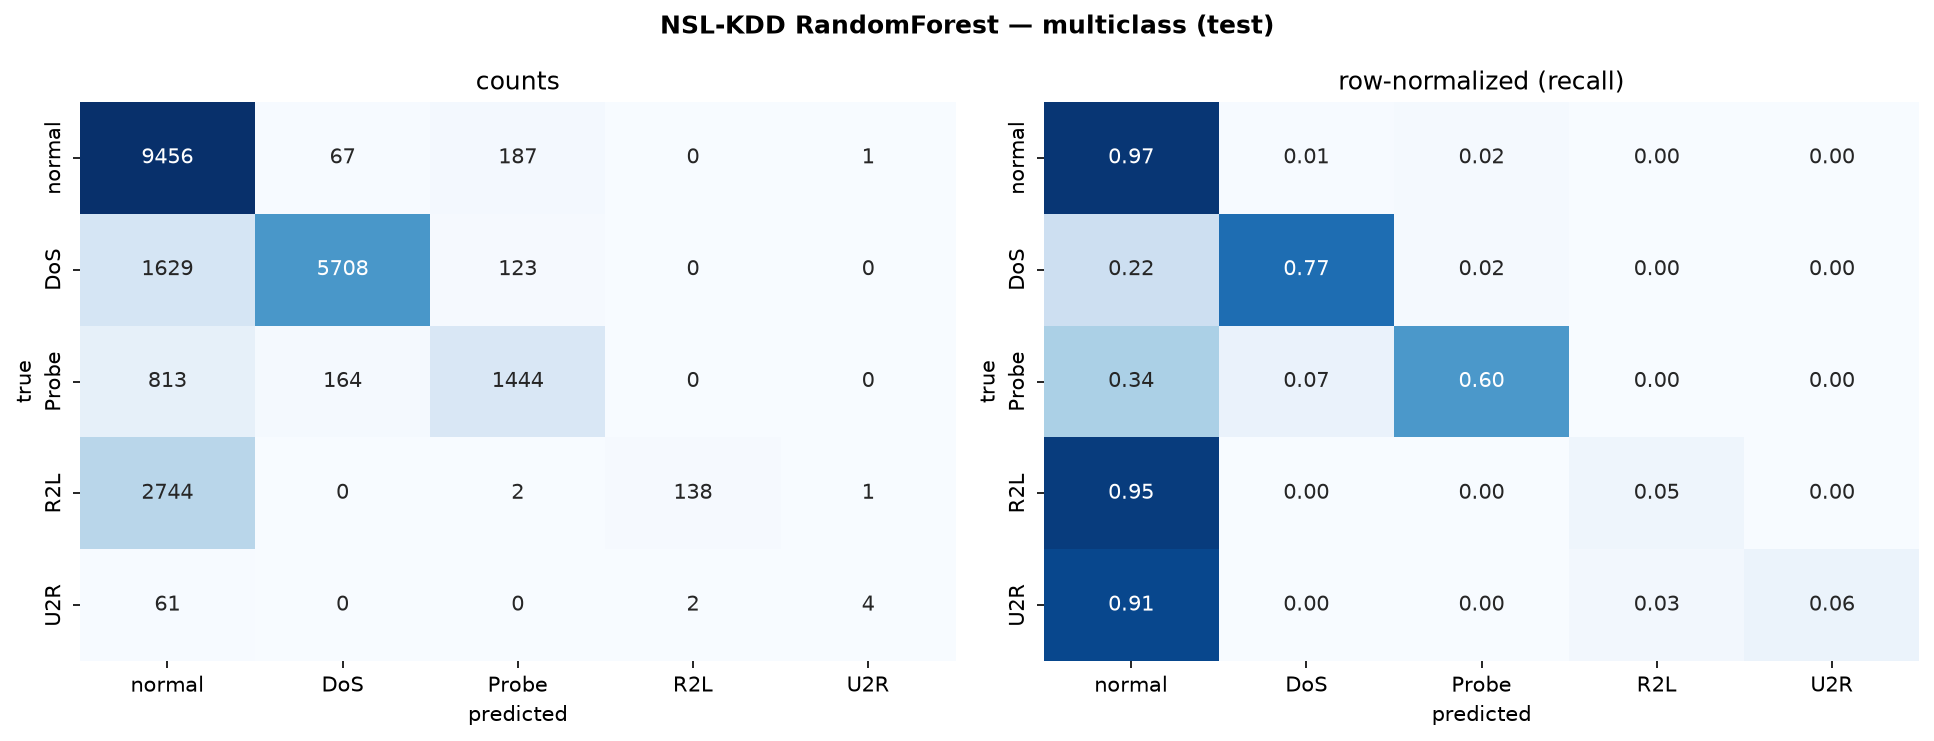

### p3_nslkdd_lightgbm_multiclass_test_confusion.png

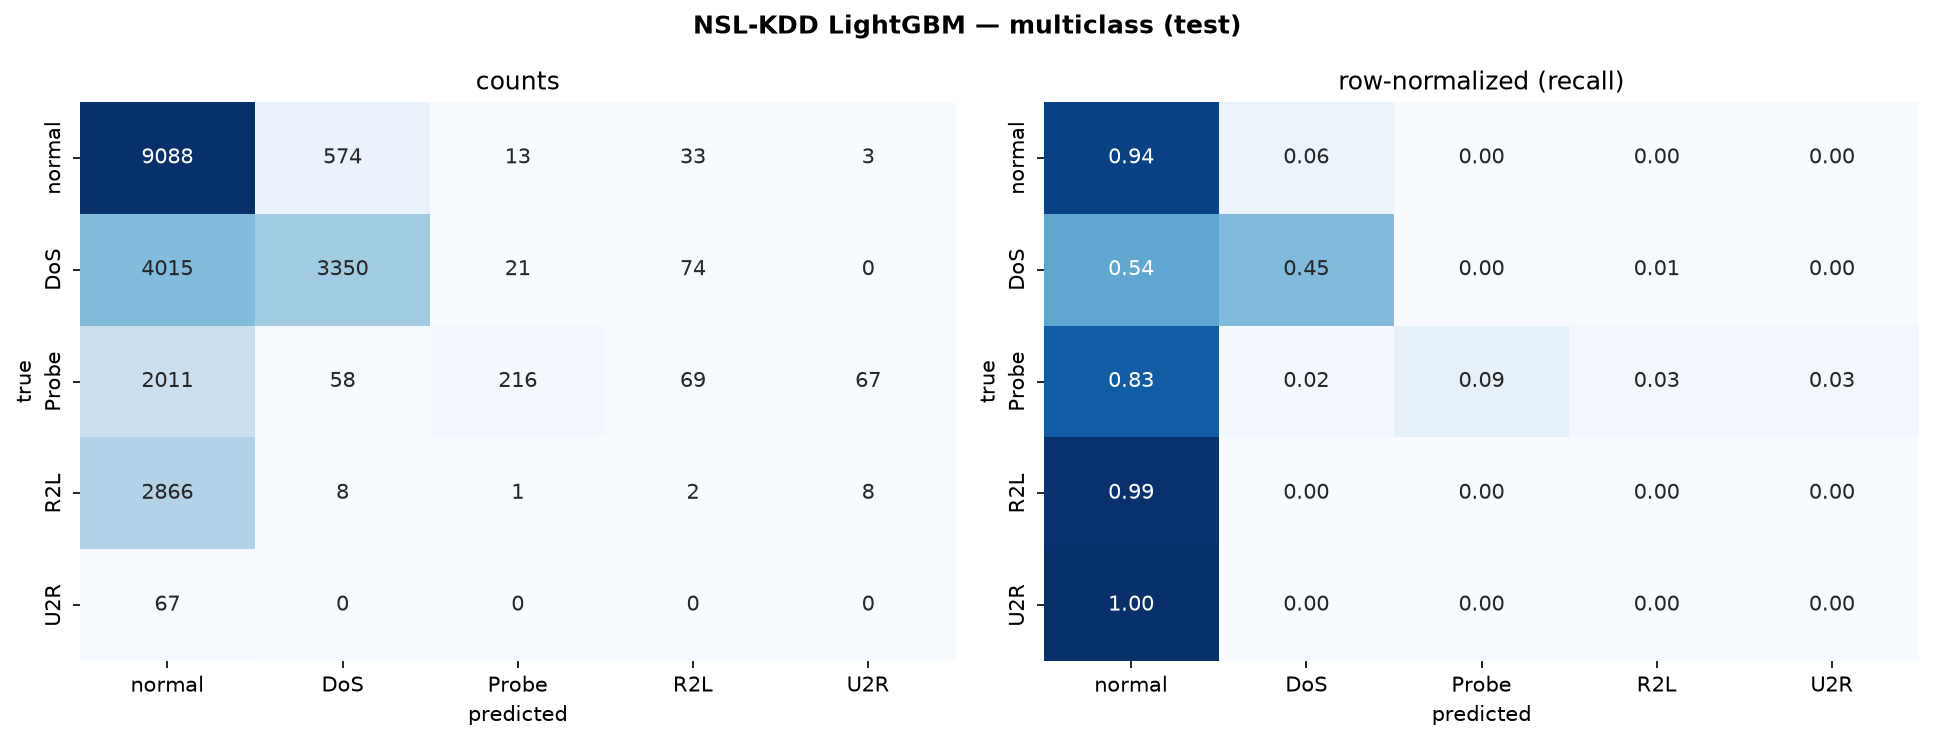

### p4_nslkdd_mlp_unweighted_multiclass_confusion.png

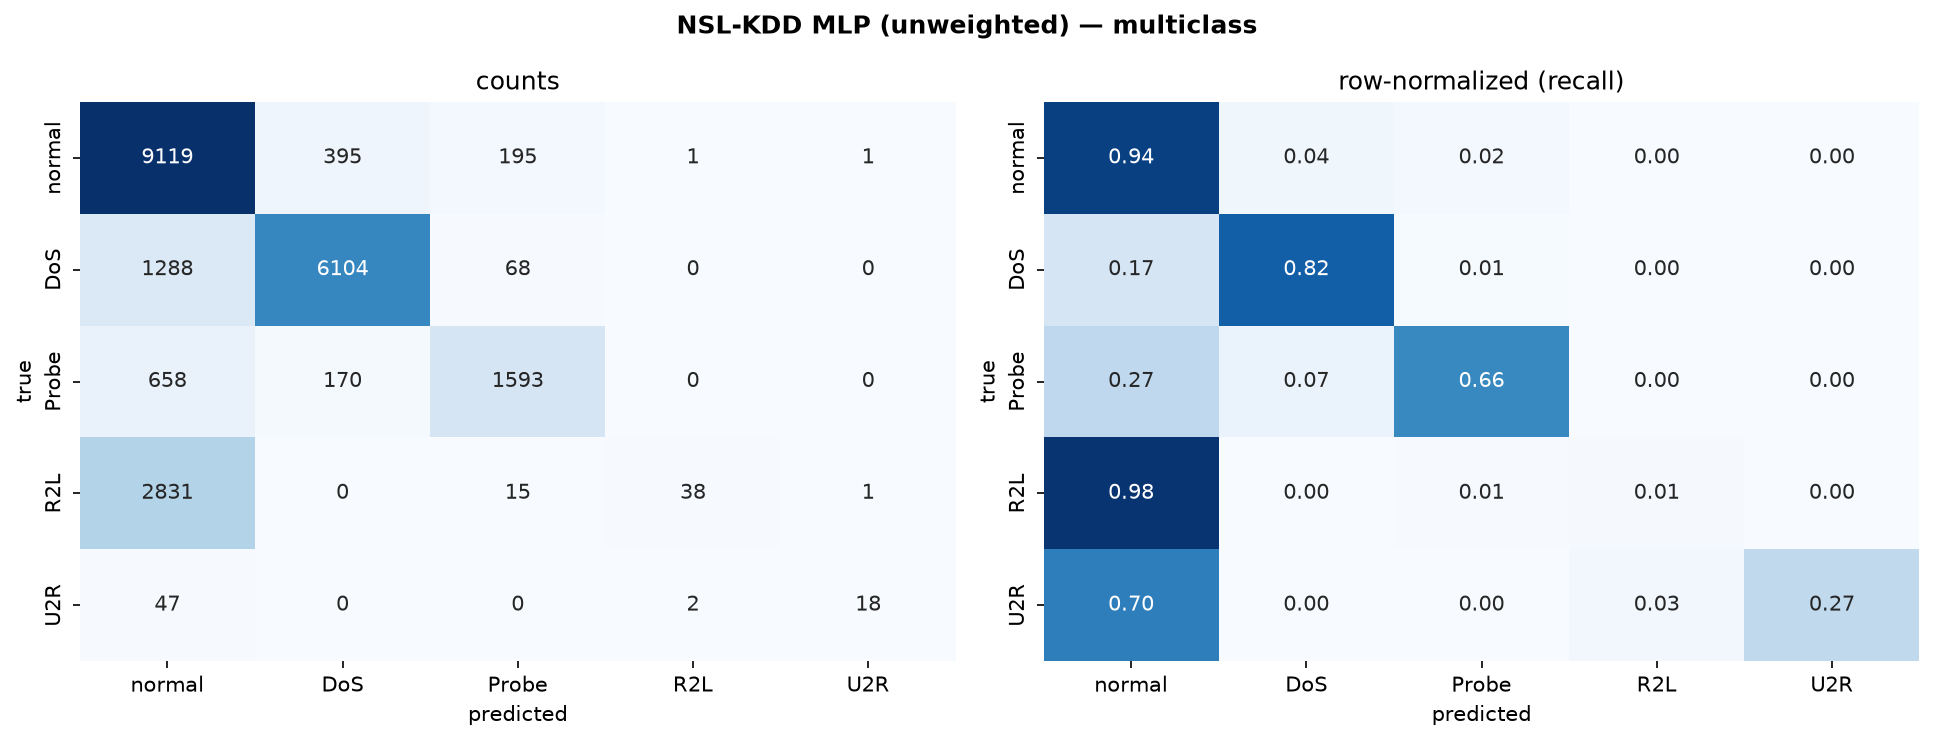

### p4_nslkdd_mlp_weighted_multiclass_confusion.png

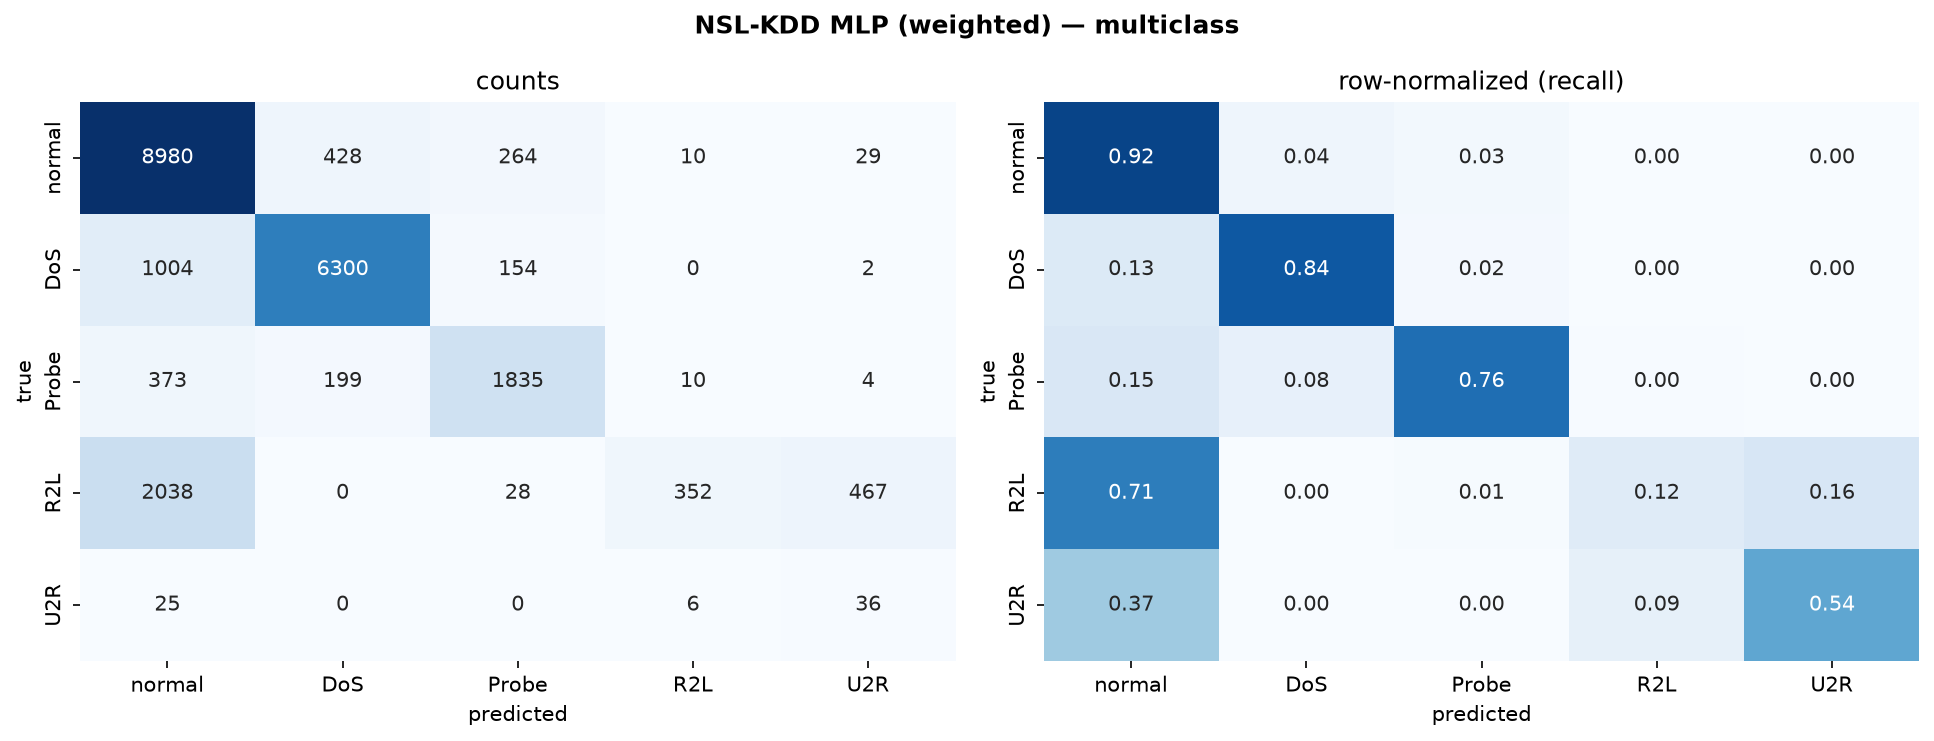

In [27]:
fig_paths = [
    REPO / "results/figures/p3_nslkdd_randomforest_multiclass_test_confusion.png",
    REPO / "results/figures/p3_nslkdd_lightgbm_multiclass_test_confusion.png",
    REPO / "results/figures/p4_nslkdd_mlp_unweighted_multiclass_confusion.png",
    REPO / "results/figures/p4_nslkdd_mlp_weighted_multiclass_confusion.png",
]
for p in fig_paths:
    if p.exists():
        display(Markdown(f"### {p.name}"))
        display(Image(filename=str(p)))
    else:
        print("missing", p)


## 9. Documentation consistency check

A reviewer will punish inconsistency. The repo currently has a specific issue: `docs/learning/03_mlp.md` still describes the earlier stronger MLP result, but `results/metrics.md` now contains the regenerated CPU result.


In [28]:
mlp_note = (REPO / "docs/learning/03_mlp.md").read_text(encoding="utf-8")
print("Current metrics.md Phase 4 table:")
display(mlp_df)

if "0.708" in mlp_note or "R2L 0.48" in mlp_note:
    print("WARNING: docs/learning/03_mlp.md still contains the older stronger weighted-MLP claim.")
else:
    print("docs/learning/03_mlp.md appears aligned with the current metrics.")

progress = (REPO / "docs/PROGRESS.md").read_text(encoding="utf-8")
if "Last updated: after Phase 1" in progress or "building now" in progress:
    print("WARNING: docs/PROGRESS.md is stale; it still describes the project as around Phase 1/2.")
else:
    print("docs/PROGRESS.md appears updated.")


Current metrics.md Phase 4 table:


,Variant,Task,Accuracy,Macro-F1,Rare-class recall
0,MLP (unweighted),binary,0.8105,0.8104,attack 0.688
1,MLP (weighted),binary,0.7975,0.7975,attack 0.700
2,MLP (unweighted),multiclass,0.7484,0.5634,R2L 0.013 / U2R 0.269
3,MLP (weighted),multiclass,0.7764,0.5605,R2L 0.122 / U2R 0.537


docs/learning/03_mlp.md appears aligned with the current metrics.
docs/PROGRESS.md appears updated.


## 10. Referee conclusions

### What is strong

1. **The project now has a real end-to-end NSL-KDD path.** Data loading, leakage-safe preprocessing, evaluation utilities, tree baselines, and MLP training all exist.
2. **The metric philosophy is correct.** Macro-F1 and per-class recall are the right center of gravity for imbalanced intrusion data.
3. **The official split is doing its job.** It exposes generalization failure that a random split would hide.
4. **Testing exists and passes.** The full pytest suite now includes the tuning-protocol tests and passes during this audit.
5. **The macOS runtime issue is understood.** The LightGBM/OpenMP crash risk is mitigated by conservative thread settings, and plotting is headless-safe.

### What the data says

1. **NSL-KDD is heavily imbalanced.** U2R has only 52 training examples, so any U2R claim must be treated carefully.
2. **The test set shifts hard.** R2L becomes much more common in test than train, and numeric/categorical distributions move too.
3. **Unseen raw attack labels exist in test.** That explains why train/CV scores can be misleadingly high.

### What the model experiments say

1. **Binary detection is decent but not production-grade.** Macro-F1 around 0.78-0.81 means many attacks are still missed at the default threshold.
2. **Rare-class multiclass detection remains the core weakness.** RF, LightGBM, and the MLP all struggle with R2L/U2R, though weighting changes the trade-off.
3. **The old “weighted MLP clearly wins” story was too strong.** The current docs now frame weighting as a rare-recall trade-off; the experiment still needs repeated seeds/devices before making a stronger claim.
4. **Balanced linear modelling is a major contender.** In the method sweep, class-weighted logistic regression with stronger regularization is the best multiclass audit result. It beats the saved MLP macro-F1 and is much easier to explain.
5. **Fine-tuning must respect dataset shift.** Random row-level train-validation tuning can choose parameters that do not survive the official `KDDTest+` shift. The next serious tuning protocol should include a raw-attack-label holdout inside the training set.
6. **Training attributes matter as much as model family.** Class weighting, regularization strength, tree depth, sample weighting, and threshold choice all move the result. The project should present that as the learning, not a simplistic model leaderboard.


## 11. Recommended working-process improvements

### Immediate fixes before presenting this project

1. **Promote logistic regression into the official baselines.** Add unweighted and `class_weight="balanced"` logistic regression to the reproducible training script/results, not only this audit notebook.
2. **Promote balanced LightGBM as an official ablation.** The saved LightGBM multiclass result is weak; the audit sweep shows class weighting materially changes it.
3. **Add a real tuning script.** Move the notebook's fine-tuning lab into a reproducible `src/tune_models.py` or configurable training CLI.
4. **Use two validation protocols.** Keep `StratifiedKFold` for stability, and add a raw-attack-label holdout to mimic unseen attack families before touching `KDDTest+`.
5. **Keep docs tied to generated metrics.** Future reruns should update `README.md`, `docs/PROGRESS.md`, and `docs/learning/` in the same pass.
6. **Record runtime context in metrics.** Add device (`cpu`/`mps`), seed, epoch count, early-stopping epoch, timestamp, and LightGBM thread settings to Phase 3/4 outputs.
7. **Run MLP over multiple seeds.** Report mean +/- std for macro-F1 and rare-class recall. One stochastic run is not enough to claim weighting wins.
8. **Save per-class MLP tables.** The Phase 4 metrics table only stores rare recall; it should save full per-class precision/recall/F1 like Phase 3.

### Modelling improvements worth doing next

1. **Threshold tuning for binary.** ROC-AUC/PR-AUC are high, but default 0.5 threshold misses many attacks. Tune a threshold on validation for attack recall / F-beta.
2. **Calibrate probabilities.** Especially if this is framed as SOC alert triage, probability calibration matters.
3. **Store predictions.** Save `y_true`, `y_pred`, and probabilities for each run. It makes later audit, plots, and error analysis much easier.
4. **Make training scripts configurable.** Add CLI flags: `--scheme`, `--model`, `--device`, `--seed`, `--runs`, `--skip-plots`, `--fast`.

### Narrative improvement

Do **not** claim “the neural network is better” too broadly. The more defensible conclusion is:

> On NSL-KDD, honest official-split evaluation and imbalance handling matter more than raw accuracy. The current MLP improves some rare-class behavior, but a class-weighted linear baseline is surprisingly strong. Fine-tuning must be judged against distribution shift, not only row-level validation scores.
